In [1]:
import pandas as pd
dataset=pd.read_csv("Placement.csv")
dataset.head()

,sl_no,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,1,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,2,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,3,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
3,4,M,56.00,Central,52.00,Central,Science,52.00,Sci&Tech,No,66.0,Mkt&HR,59.43,Not Placed,NaN
4,5,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0


# Covariance

In [3]:
numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
dataset[numerical_cols].cov()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,117.228377,60.348373,42.897137,37.659225,24.535952,2.877739e+04
hsc_p,60.348373,118.755706,34.819820,35.461678,22.555846,6.697772e+04
degree_p,42.897137,34.819820,54.151103,21.929469,17.272020,-1.173995e+04
etest_p,37.659225,35.461678,21.929469,176.251018,16.886973,2.287876e+05
mba_p,24.535952,22.555846,17.272020,16.886973,34.028376,9.624979e+04
salary,28777.386468,66977.716032,-11739.948520,228787.619507,96249.789024,8.734295e+09


# Correlation

In [5]:
numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
dataset[numerical_cols].corr()

,ssc_p,hsc_p,degree_p,etest_p,mba_p,salary
ssc_p,1.000000,0.511472,0.538404,0.261993,0.388478,0.035330
hsc_p,0.511472,1.000000,0.434206,0.245113,0.354823,0.076819
degree_p,0.538404,0.434206,1.000000,0.224470,0.402364,-0.019272
etest_p,0.261993,0.245113,0.224470,1.000000,0.218055,0.178307
mba_p,0.388478,0.354823,0.402364,0.218055,1.000000,0.175013
salary,0.035330,0.076819,-0.019272,0.178307,0.175013,1.000000


In [7]:
numerical_cols = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
dataset[numerical_cols].corrwith(dataset['mba_p'])

,0
ssc_p,0.388478
hsc_p,0.354823
degree_p,0.402364
etest_p,0.218055
mba_p,1.000000
salary,0.175013


# Preprocessing

In [8]:
dataset=dataset.drop(columns='sl_no')
dataset=dataset.dropna()

# Visulaize the pair

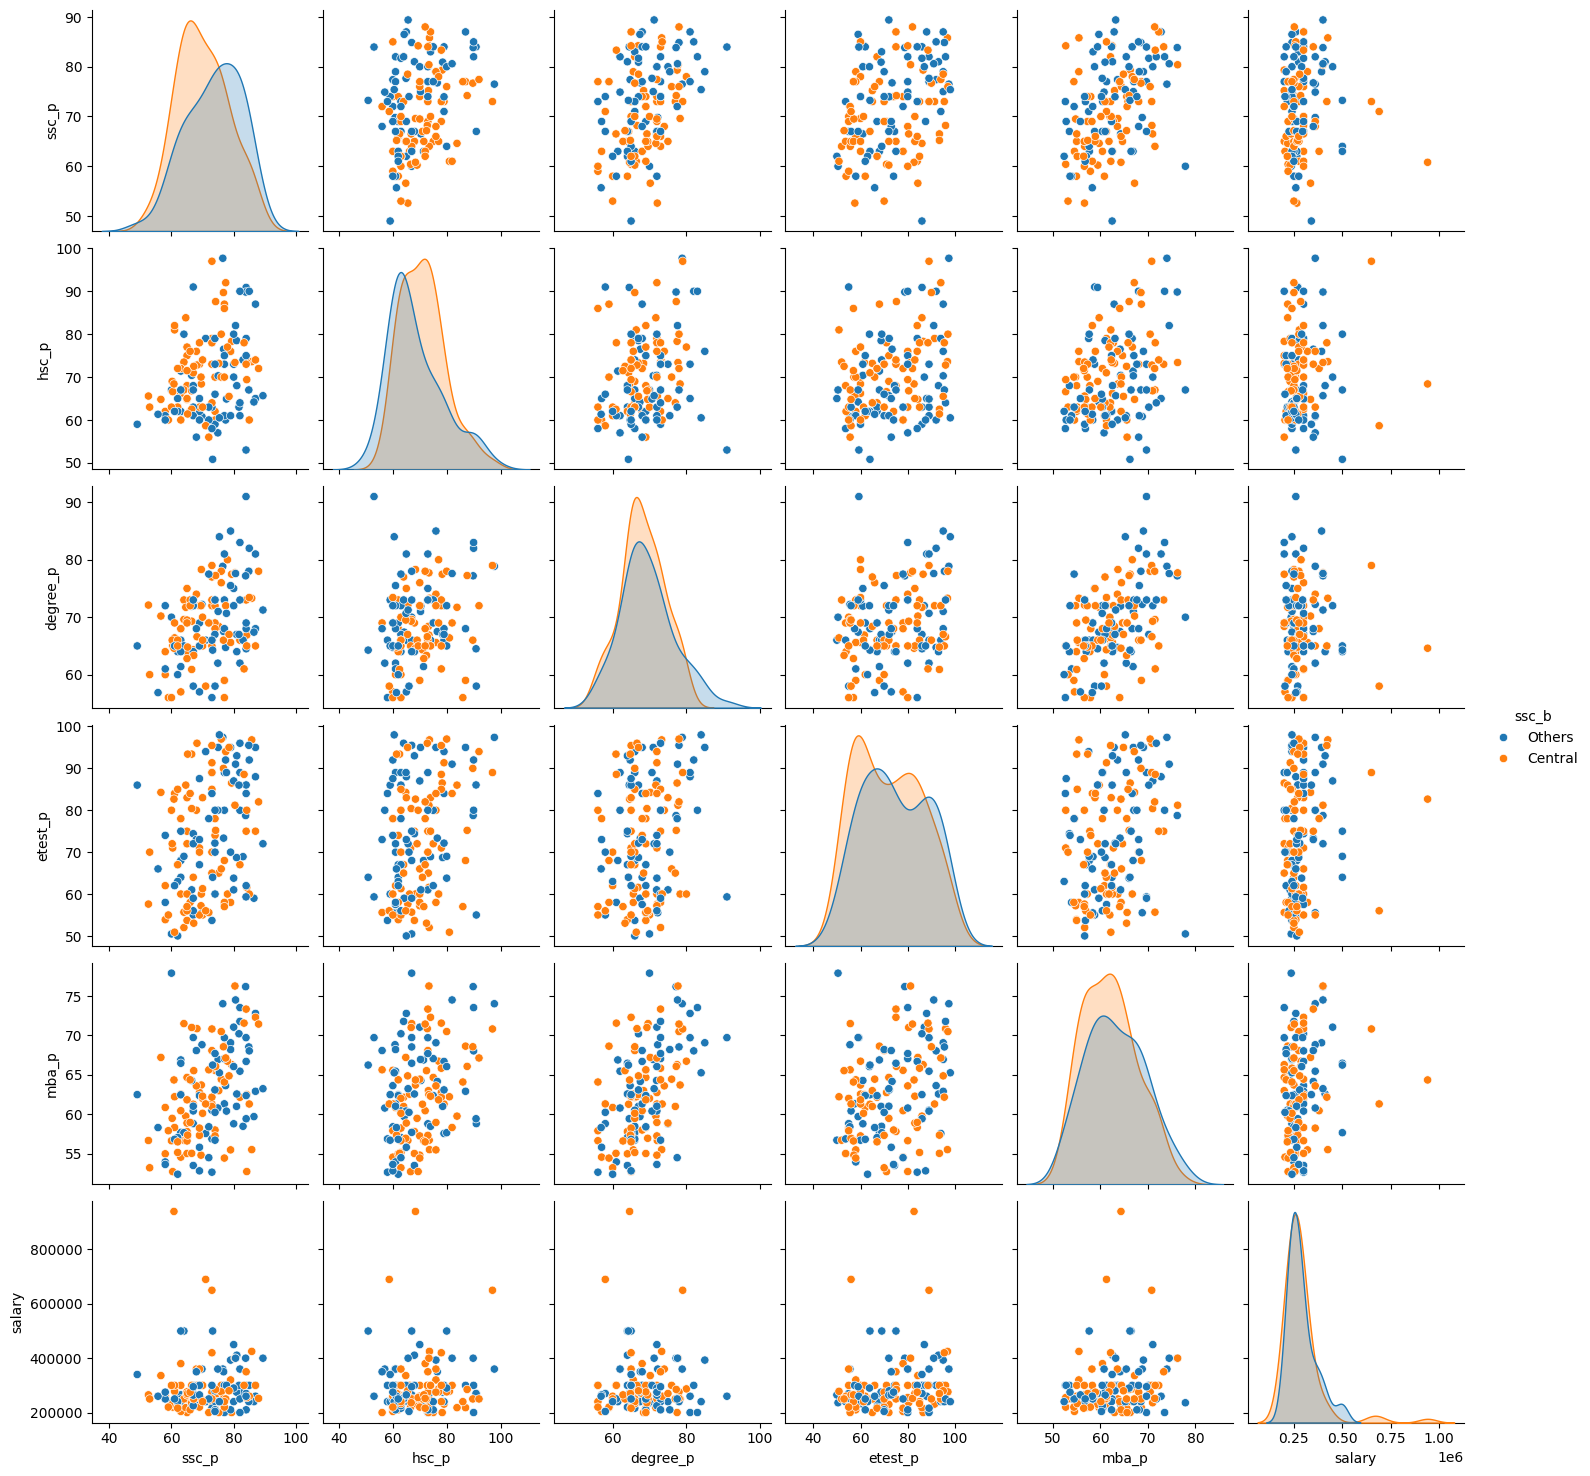

In [9]:
import seaborn as sns
sns.pairplot(dataset,hue="ssc_b")

import matplotlib.pyplot as plt
plt.savefig('pairplot_ssc_b.png')

# Calling user defined function Descriptive file

In [12]:
import pandas as pd

class Descriptive:
    def segreQuanQual(self, dataset):
        quan = []
        qual = []
        for columnName in dataset.columns:
            if dataset[columnName].dtype == 'object':
                qual.append(columnName)
            else:
                quan.append(columnName)
        print("The Quantitative Data:", quan)
        print("The Qualtitative Data", qual)
        return quan, qual

obj=Descriptive()

# Sregrating quantitative Data and qualtative

In [13]:
quan,qual=obj.segreQuanQual(dataset)

The Quantitative Data: ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p', 'salary']
The Qualtitative Data ['gender', 'ssc_b', 'hsc_b', 'hsc_s', 'degree_t', 'workex', 'specialisation', 'status']


In [14]:
quan_data=dataset[quan]

In [16]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calc_vif(X):

    vif = pd.DataFrame()
    vif["variables"] = X.columns
    vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

    return(vif)


In [17]:
calc_vif(quan_data)

,variables,VIF
0,ssc_p,92.542386
1,hsc_p,64.913495
2,degree_p,133.057116
3,etest_p,35.980186
4,mba_p,167.558834
5,salary,11.166150


In [18]:
quan_data=dataset[['etest_p','salary',]]

# Univarite Analysis

## Probability Density Function(PDF)

/tmp/ipykernel_6712/2559061110.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset['ssc_p'],kde=True)


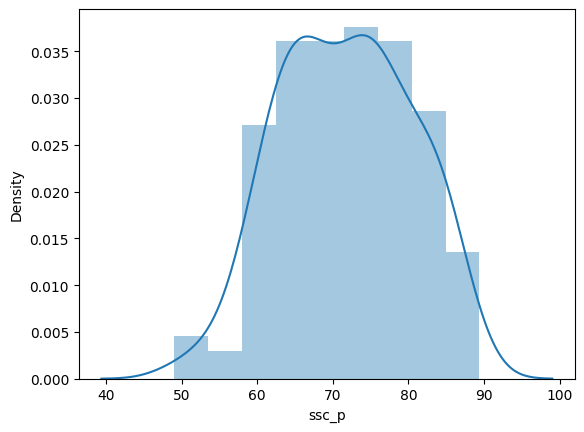

In [19]:

import seaborn as sns
x=dataset['ssc_p']
ax = sns.distplot(dataset['ssc_p'],kde=True)

In [20]:
def get_pdf_probability(dataset,startrange,endrange):
    from matplotlib import pyplot
    from scipy.stats import norm
    import seaborn as sns
    ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')
    pyplot.axvline(startrange,color='Red')
    pyplot.axvline(endrange,color='Red')
    sample = dataset
    sample_mean =sample.mean()
    sample_std = sample.std()
    print('Mean=%.3f, Standard Deviation=%.3f' % (sample_mean, sample_std))
    dist = norm(sample_mean, sample_std)

    values = [value for value in range(startrange, endrange)]
    probabilities = [dist.pdf(value) for value in values]
    prob=sum(probabilities)
    print("The area between range({},{}):{}".format(startrange,endrange,sum(probabilities)))
    return prob


Mean=71.721, Standard Deviation=8.715
The area between range(60,60):0


/tmp/ipykernel_6712/4157074001.py:5: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  ax = sns.distplot(dataset,kde=True,kde_kws={'color':'blue'},color='Green')


0

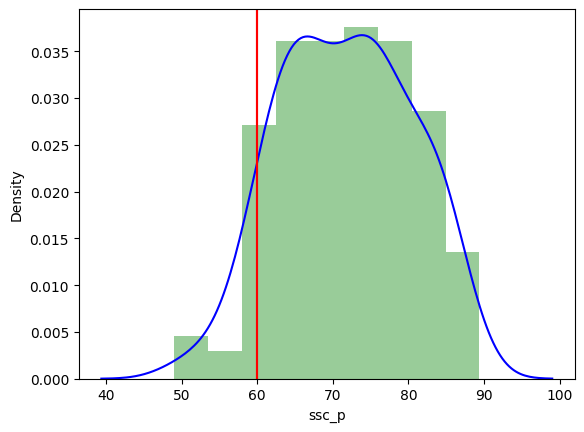

In [21]:
get_pdf_probability(dataset['ssc_p'],60,60)

# cumulative Density function

(array([0.00675676, 0.00675676, 0.00675676, 0.00675676, 0.00675676,
        0.00675676, 0.00675676, 0.00675676, 0.01351351, 0.02027027,
        0.02027027, 0.02027027, 0.02027027, 0.02027027, 0.02027027,
        0.02027027, 0.02702703, 0.02702703, 0.03378378, 0.03378378,
        0.03378378, 0.03378378, 0.06081081, 0.06081081, 0.06756757,
        0.06756757, 0.06756757, 0.08783784, 0.09459459, 0.12162162,
        0.12162162, 0.12162162, 0.15540541, 0.15540541, 0.2027027 ,
        0.2027027 , 0.2027027 , 0.22297297, 0.22972973, 0.27702703,
        0.28378378, 0.28378378, 0.2972973 , 0.31756757, 0.36486486,
        0.36486486, 0.36486486, 0.38513514, 0.38513514, 0.42567568,
        0.43918919, 0.46621622, 0.46621622, 0.46621622, 0.47972973,
        0.47972973, 0.5       , 0.5       , 0.5       , 0.56756757,
        0.56756757, 0.61486486, 0.62162162, 0.62162162, 0.64189189,
        0.64864865, 0.66216216, 0.66216216, 0.68243243, 0.72297297,
        0.74324324, 0.75      , 0.75      , 0.75

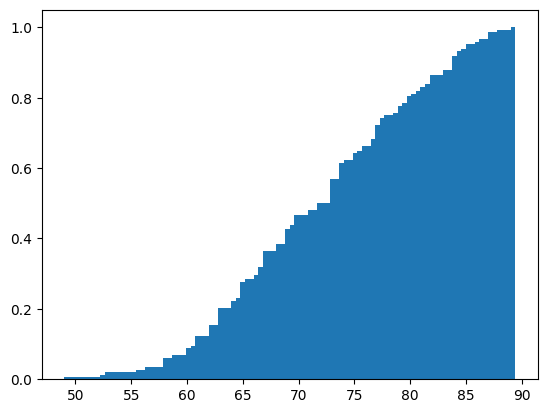

In [22]:
import matplotlib.pyplot as plt
x=dataset['ssc_p']
plt.hist(x,cumulative=True, density=True,bins=100)

In [23]:
from statsmodels.distributions.empirical_distribution import ECDF
ecdf = ECDF(dataset['ssc_p'])
ecdf(65)

np.float64(0.277027027027027)

# Types of Test

# Z- Score: Normal distribution to Standard Normal Distribution

/tmp/ipykernel_6712/4389396.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(dataset['ssc_p'],kde=True)


<Axes: xlabel='ssc_p', ylabel='Density'>

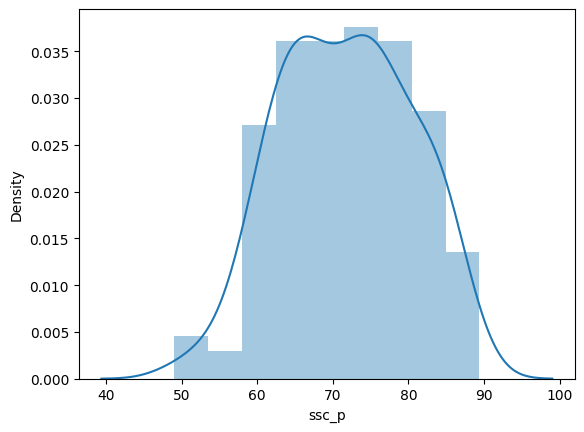

In [24]:
import seaborn as sns
sns.distplot(dataset['ssc_p'],kde=True)

Mean of z_score: -1.2902591907805873e-15
Standard Deviation of z_score: 0.9999999999999998


/tmp/ipykernel_6712/726650685.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(z_score,kde=True)


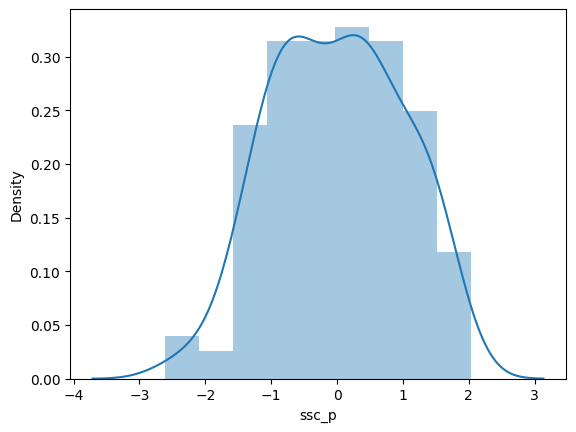

In [26]:
import seaborn as sns
mean=dataset['ssc_p'].mean()
std=dataset['ssc_p'].std()

z_score = (dataset['ssc_p'] - mean) / std

sns.distplot(z_score,kde=True)

print(f"Mean of z_score: {z_score.mean()}")
print(f"Standard Deviation of z_score: {z_score.std()}")

In [27]:
dataset

,gender,ssc_p,ssc_b,hsc_p,hsc_b,hsc_s,degree_p,degree_t,workex,etest_p,specialisation,mba_p,status,salary
0,M,67.00,Others,91.00,Others,Commerce,58.00,Sci&Tech,No,55.0,Mkt&HR,58.80,Placed,270000.0
1,M,79.33,Central,78.33,Others,Science,77.48,Sci&Tech,Yes,86.5,Mkt&Fin,66.28,Placed,200000.0
2,M,65.00,Central,68.00,Central,Arts,64.00,Comm&Mgmt,No,75.0,Mkt&Fin,57.80,Placed,250000.0
4,M,85.80,Central,73.60,Central,Commerce,73.30,Comm&Mgmt,No,96.8,Mkt&Fin,55.50,Placed,425000.0
7,M,82.00,Central,64.00,Central,Science,66.00,Sci&Tech,Yes,67.0,Mkt&Fin,62.14,Placed,252000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
209,M,62.00,Central,72.00,Central,Commerce,65.00,Comm&Mgmt,No,67.0,Mkt&Fin,56.49,Placed,216000.0
210,M,80.60,Others,82.00,Others,Commerce,77.60,Comm&Mgmt,No,91.0,Mkt&Fin,74.49,Placed,400000.0
211,M,58.00,Others,60.00,Others,Science,72.00,Sci&Tech,No,74.0,Mkt&Fin,53.62,Placed,275000.0
212,M,67.00,Others,67.00,Others,Commerce,73.00,Comm&Mgmt,Yes,59.0,Mkt&Fin,69.72,Placed,295000.0


In [28]:
dataset[dataset["gender"]=="M"]["salary"]

,salary
0,270000.0
1,200000.0
2,250000.0
4,425000.0
7,252000.0
...,...
207,300000.0
209,216000.0
210,400000.0
211,275000.0


# T-Test

#### Independant Sample
Diferrent Group(Male, Female) but same contion(salary)

In [29]:
from scipy.stats import ttest_ind
dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['salary']
female = dataset[dataset['gender']=='F']['salary']
print(male)
ttest_ind(male, female)

0      270000.0
1      200000.0
2      250000.0
4      425000.0
7      252000.0
         ...   
207    300000.0
209    216000.0
210    400000.0
211    275000.0
212    295000.0
Name: salary, Length: 100, dtype: float64


TtestResult(statistic=np.float64(1.9448521615505496), pvalue=np.float64(0.053714668806405776), df=np.float64(146.0))

#### Dependant Sample
Same Group(Male) but Different Condition(ssc_p,hsc_p)


In [30]:
from scipy.stats import ttest_rel
dataset=dataset.dropna()
male = dataset[dataset['gender']=='M']['ssc_p']
male1 = dataset[dataset['gender']=='M']['hsc_p']
ttest_rel(male, male1)


TtestResult(statistic=np.float64(0.881726473207718), pvalue=np.float64(0.38006050142386016), df=np.int64(99))

### for one sample mean

should same for different sample

scipy.stats.ttest_1samp(a, popmean, axis=0, nan_policy='propagate')

# ANAVO : Analysis of Variance

## One-Way Classification

In [31]:
import scipy.stats as stats

stats.f_oneway(dataset['ssc_p'],dataset['hsc_p'],dataset['degree_p'])


F_onewayResult(statistic=np.float64(4.866998084927852), pvalue=np.float64(0.008114829524764158))

In [34]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd

print("Counts of gender and workex combinations:\n", pd.crosstab(dataset['gender'], dataset['workex']))

model = ols('degree_p ~ C(gender) + C(workex) + C(gender):C(workex)', data=dataset).fit()
sm.stats.anova_lm(model, typ=2)

Counts of gender and workex combinations:
 workex  No  Yes
gender         
F       30   18
M       54   46


,sum_sq,df,F,PR(>F)
C(gender),247.074384,1.0,5.946285,0.015966
C(workex),2.344866,1.0,0.056433,0.812562
C(gender):C(workex),14.865283,1.0,0.357760,0.550693
Residual,5983.350757,144.0,NaN,NaN
